# Predict speedup plot

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")


def get_all_records_bench_speedup():
    dfs = []
    for p in RESULTS_DIR.glob("bench_speedup_dataset.*.csv"):
        run_id = p.stem.replace("bench_speedup_dataset.", "", 1)
        df = pd.read_csv(p)
        df["run_id"] = run_id
        dfs.append(df)
    df_all = pd.concat(dfs, ignore_index=True)
    return df_all


df_all_records = get_all_records_bench_speedup()
df_all_records.head()


,n_samples,n_features,n_threads,n_cpus,system,machine,fit_time,predict_time,fit_speedup,predict_speedup,run_id
0,100,10,1,8,Linux,x86_64,0.024420,0.000866,1.000000,1.000000,20260403_083532
1,100,10,2,8,Linux,x86_64,0.034124,0.000763,0.715636,1.134626,20260403_083532
2,100,10,3,8,Linux,x86_64,0.036038,0.000710,0.677631,1.220333,20260403_083532
3,100,10,4,8,Linux,x86_64,0.036264,0.000713,0.673407,1.215421,20260403_083532
4,100,10,5,8,Linux,x86_64,0.038194,0.000709,0.639377,1.220758,20260403_083532


In [2]:
df_all_records["machine"].unique().tolist()

['x86_64', 'aarch64', 'arm64']

In [3]:
df_all_records["n_samples"].unique().tolist()


[100, 316, 1000, 3162, 10000, 31622, 100000, 316227, 1000000]

In [4]:
def plot_predict_speedup(machine, n_cpus, n_samples_list):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    for n_samples in n_samples_list:
        df = df_all_records.query(
            f"machine=='{machine}' & n_samples=={n_samples} & n_cpus=={n_cpus}"
        )
        ax.semilogy(df["n_threads"], df["predict_speedup"], ".", label=f"{n_samples=}")
    ax.set(xlabel="Threads", ylabel="predict_speedup", title=f"{machine} {n_cpus}cpus")
    ax.set_yticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
    ax.set_yticklabels(["0.1×", "0.2×", "0.5×", "1×", "2×", "5×", "10×"])
    ax.legend()

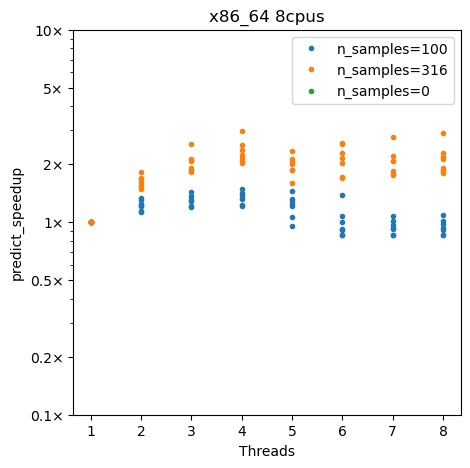

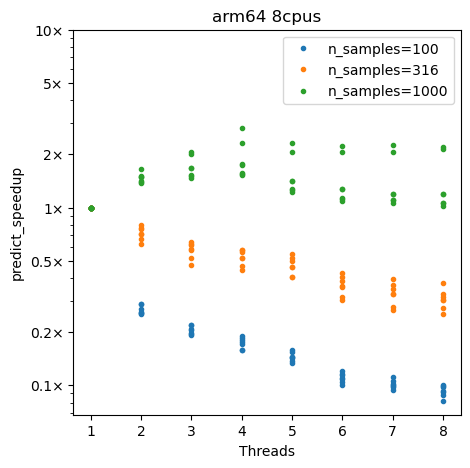

In [5]:
# Linux intel
plot_predict_speedup("x86_64", 8, [100, 316, 000])
# Mac (M3 4 efficiency + 4 performance cores)
plot_predict_speedup("arm64", 8, [100, 316, 1000])


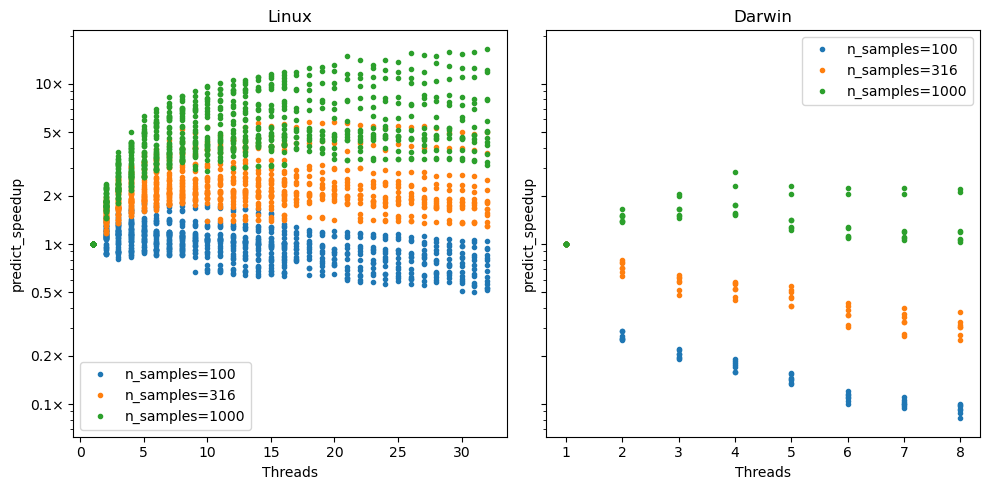

In [6]:
def plot_predict_speedup_all(n_samples_list):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
    systems = ["Linux", "Darwin"]
    for system, ax in zip(systems, axs):
        for n_samples in n_samples_list:
            df = df_all_records.query(f"system=='{system}' & n_samples=={n_samples}")
            ax.semilogy(
                df["n_threads"], df["predict_speedup"], ".", label=f"{n_samples=}"
            )
        ax.set(xlabel="Threads", ylabel="predict_speedup", title=f"{system}")
        ax.set_yticks([0.1, 0.2, 0.5, 1, 2, 5, 10])
        ax.set_yticklabels(["0.1×", "0.2×", "0.5×", "1×", "2×", "5×", "10×"])
        ax.legend()
    fig.tight_layout()


plot_predict_speedup_all([100, 316, 1000])